<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/correlation_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [35]:
import os
from getpass import getpass

TOKEN = getpass('Enter GitHub token: ')
REPO = "milleau98/2026-gig-data-analysis"

if not os.path.exists("2026-gig-data-analysis"):
    !git clone https://{TOKEN}@github.com/{REPO}.git
else:
    %cd 2026-gig-data-analysis
    !git pull

Enter GitHub token: ··········
Cloning into '2026-gig-data-analysis'...
remote: Enumerating objects: 609, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 609 (delta 102), reused 46 (delta 37), pack-reused 443 (from 1)
Receiving objects: 100% (609/609), 35.47 MiB | 11.98 MiB/s, done.
Resolving deltas: 100% (295/295), done.


In [36]:
import os

os.listdir()

['data',
 'notebooks',
 '.git',
 '2026-gig-data-analysis',
 'README.md',
 'google_trends.ipynb',
 '.gitignore']

In [37]:
os.listdir('2026-gig-data-analysis')

['data', 'notebooks', '.git', 'README.md', 'google_trends.ipynb', '.gitignore']

In [38]:
os.listdir('2026-gig-data-analysis/data')

['google_trends', 'fred', 'final', 'yfinance']

In [39]:
import pandas as pd

# stock price

gig_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data

google_df_monthly = pd.read_csv('2026-gig-data-analysis/data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data

fred_df_monthly = pd.read_csv('2026-gig-data-analysis/data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()



,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [41]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

# Create target variable = close/cpi_data_monthly

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# Create target variable = close/cpi_data_monthly

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [42]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()

/tmp/ipykernel_1592/167519435.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_1592/167519435.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,2.28,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,2.50,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,2.63,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,2.79,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,3.00,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8


In [43]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,SP500
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,SP500
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,SP500
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,SP500


In [66]:
import scipy.stats as stats

# Define economic stress periods

df['unemployment_z'] = stats.zscore(df['unemployment_data_monthly'].fillna(method='ffill'))
df['cpi_z'] = stats.zscore(df['cpi_data_monthly'].fillna(method='ffill'))
df['consumer_sentiment_z'] = stats.zscore(df['consumer_sentiment_data_monthly'].fillna(method='ffill'))

# Define stress based on z-score threshold
df['EconomicStress'] = (
    (df['unemployment_z'] > 1) |      # high unemployment
    (df['cpi_z'] > 1) |               # high inflation
    (df['consumer_sentiment_z'] < -1) # low consumer sentiment
)
df.head()

/tmp/ipykernel_1592/3338518284.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['unemployment_z'] = stats.zscore(df['unemployment_data_monthly'].fillna(method='ffill'))
/tmp/ipykernel_1592/3338518284.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['cpi_z'] = stats.zscore(df['cpi_data_monthly'].fillna(method='ffill'))
/tmp/ipykernel_1592/3338518284.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['consumer_sentiment_z'] = stats.zscore(df['consumer_sentiment_data_monthly'].fillna(method='ffill'))


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress,unemployment_z,cpi_z,consumer_sentiment_z
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,NaN,NaN,NaN,NaN,NaN,SP500,False,-0.179293,-1.584569,1.221996
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,NaN,0.004175,0.1,0.22,-1.4,SP500,False,-0.131845,-1.562412,1.118836
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,NaN,0.003638,-0.2,0.13,-1.5,SP500,False,-0.226741,-1.543024,1.008307
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,NaN,0.003107,0.0,0.16,-4.9,SP500,False,-0.226741,-1.526406,0.647247
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,NaN,-0.000516,-0.1,0.21,-0.8,SP500,False,-0.274189,-1.529176,0.588298


# Correlation Matrix

In [67]:
df.groupby(['EconomicStress','CompanyType'])['Return'].mean()

EconomicStress  CompanyType
False           Gig            0.012793
                MLM            0.014831
                SP500          0.012498
True            Gig            0.017489
                MLM            0.009450
                SP500          0.014954
Name: Return, dtype: float64

In [68]:
df.groupby(['EconomicStress','CompanyType'])['Target_change'].mean()

EconomicStress  CompanyType
False           Gig            0.010046
                MLM            0.012757
                SP500          0.010374
True            Gig            0.015013
                MLM            0.007146
                SP500          0.012737
Name: Target_change, dtype: float64

In [47]:
# Compute summary statistics by CompanyType and EconomicStress

summary_table = df.groupby(['CompanyType','EconomicStress']).agg({
    'Return':'mean',
    'Target_change':'mean',
    'Search_change':'mean'
}).reset_index()

print(summary_table)

  CompanyType  EconomicStress    Return  Target_change  Search_change
0         Gig           False  0.030497       0.028949       0.102362
1         Gig            True  0.014424       0.011755      -0.020824
2         MLM           False  0.023511       0.021690      -0.046296
3         MLM            True  0.008858       0.006567       0.000000
4       SP500           False  0.015380       0.013544            NaN
5       SP500            True  0.012958       0.010680            NaN


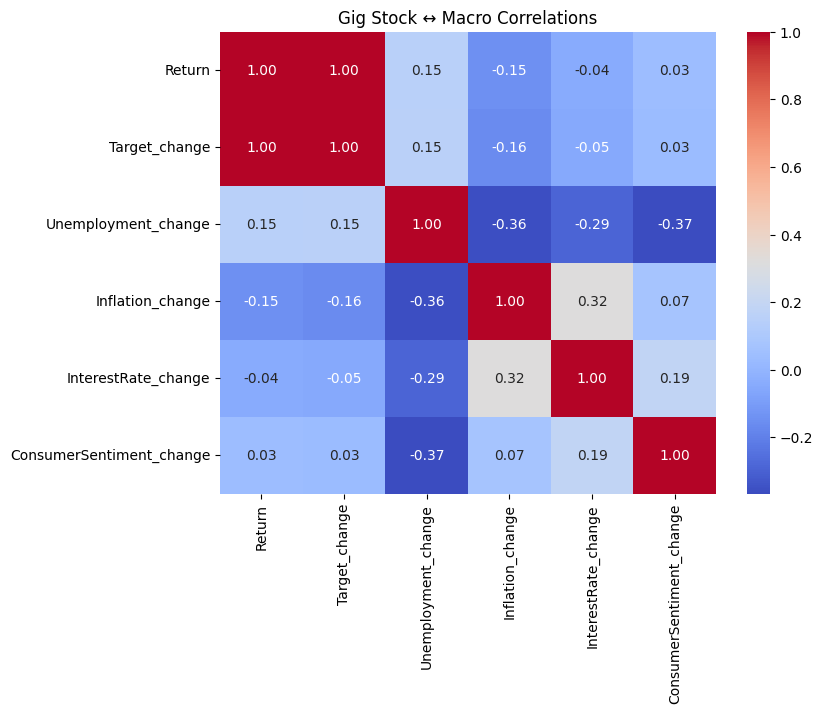

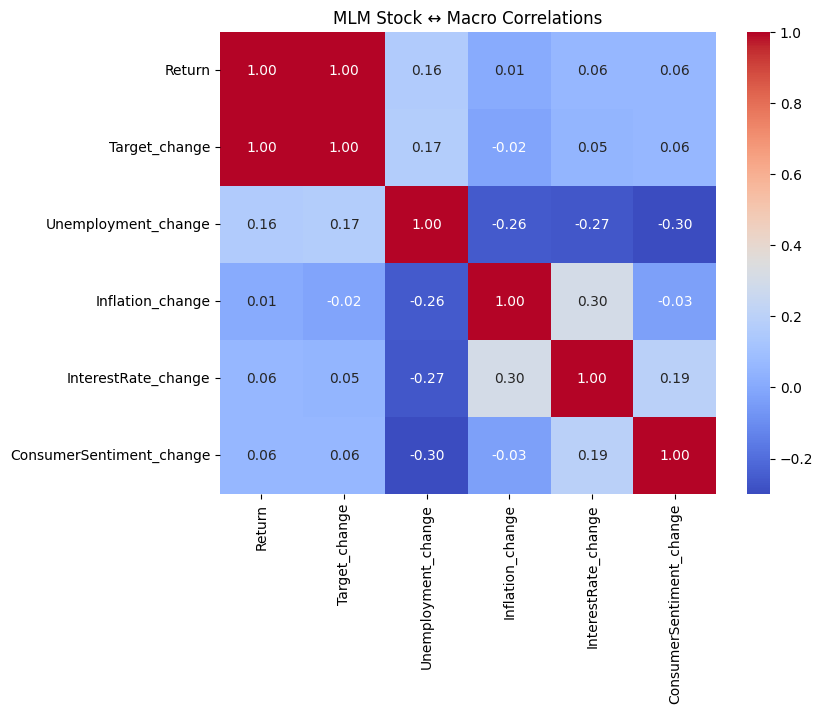

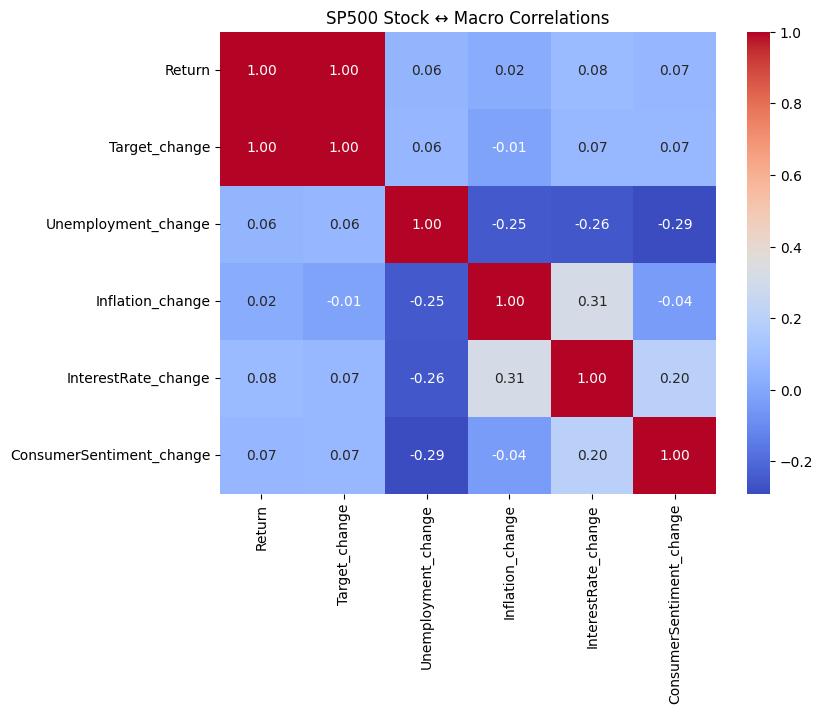

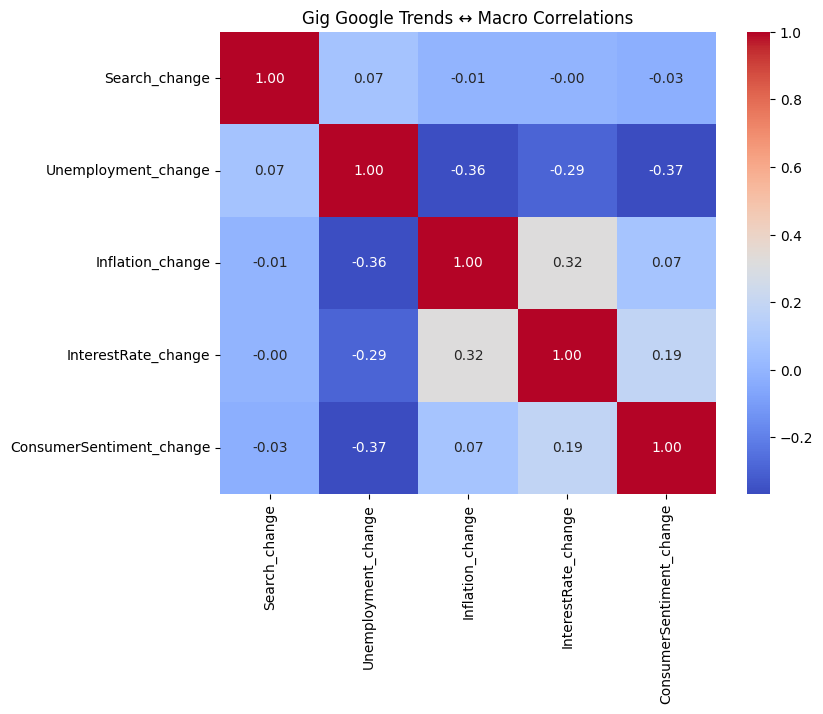

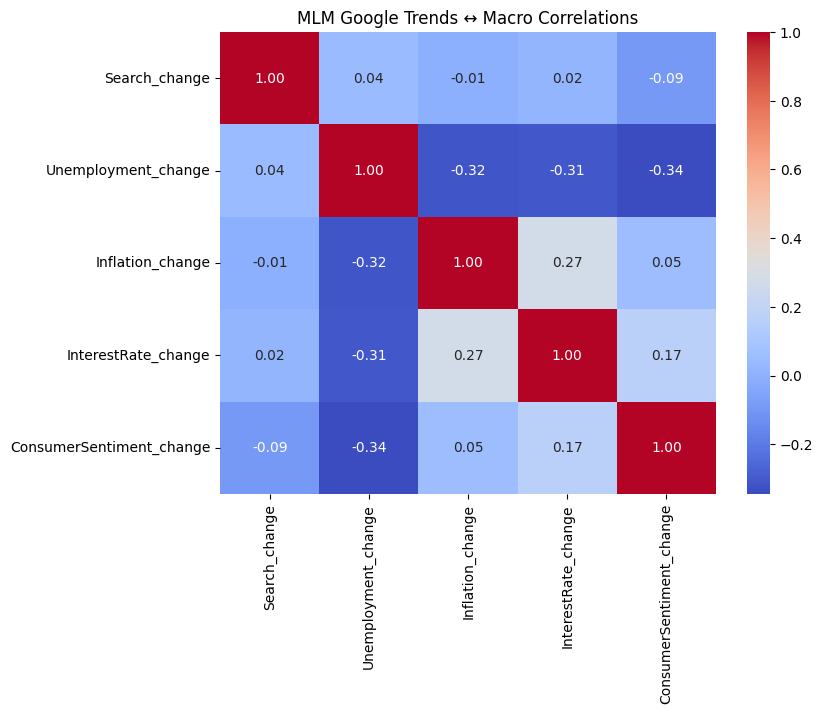

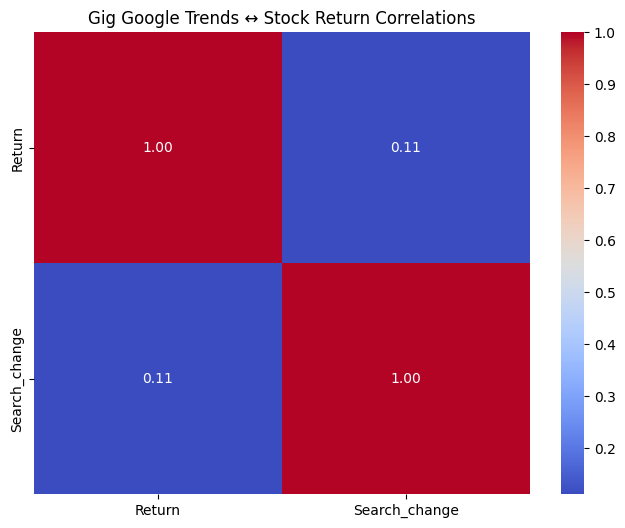

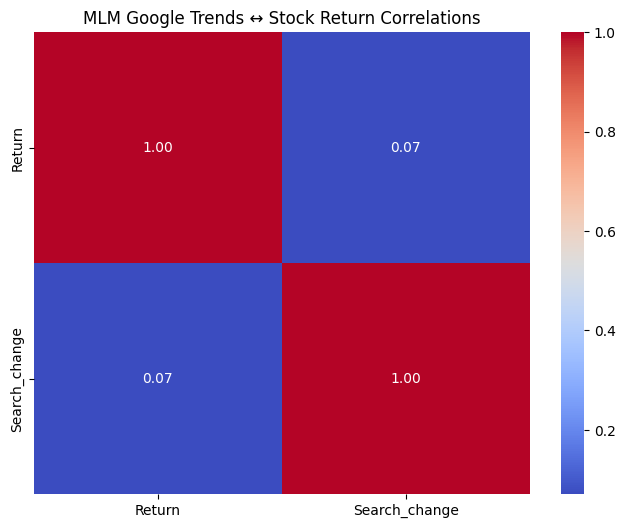

In [70]:
# Define correlation matrices
cols_stock_macro = [
    'Return',
    'Target_change',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

cols_trends_macro = [
    'Search_change',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change'
]

cols_trends_stock = [
    'Return',
    'Search_change'
]

# Function to plot heatmap
def plot_corr_matrix(df_corr, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(title)
    plt.show()

# Macro ↔ Stock returns correlations

for g in ['Gig','MLM','SP500']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_stock_macro].dropna().corr()
    plot_corr_matrix(corr, f"{g} Stock ↔ Macro Correlations")

# Macro ↔ Google Trends correlations

for g in ['Gig','MLM']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_trends_macro].dropna().corr()
    plot_corr_matrix(corr, f"{g} Google Trends ↔ Macro Correlations")


# Google Trends ↔ Stock returns correlations

for g in ['Gig','MLM']:
    temp = df[df['CompanyType']==g]
    corr = temp[cols_trends_stock].dropna().corr()
    plot_corr_matrix(corr, f"{g} Google Trends ↔ Stock Return Correlations")


In [71]:
gig_df = df[df['CompanyType'] == 'Gig']
MLM_df = df[df['CompanyType'] == 'MLM']
SP500_df = df[df['CompanyType'] == 'SP500']

SP500_df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress,unemployment_z,cpi_z,consumer_sentiment_z
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,NaN,NaN,NaN,NaN,NaN,SP500,False,-0.179293,-1.584569,1.221996
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,NaN,0.004175,0.1,0.22,-1.4,SP500,False,-0.131845,-1.562412,1.118836
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,NaN,0.003638,-0.2,0.13,-1.5,SP500,False,-0.226741,-1.543024,1.008307
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,NaN,0.003107,0.0,0.16,-4.9,SP500,False,-0.226741,-1.526406,0.647247
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,NaN,-0.000516,-0.1,0.21,-0.8,SP500,False,-0.274189,-1.529176,0.588298


# Economic Stress Analysis

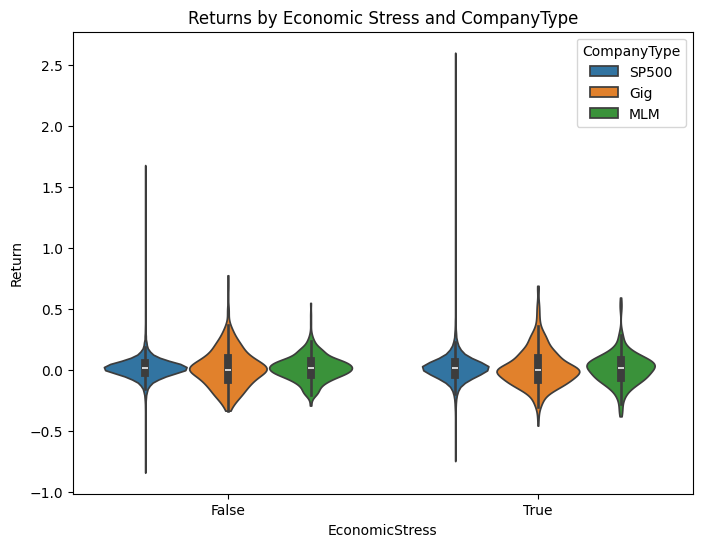

In [72]:
# Violin plot: Return distribution by EconomicStress

plt.figure(figsize=(8,6))
sns.violinplot(x='EconomicStress', y='Return', hue='CompanyType', data=df, cut=0)
plt.title("Returns by Economic Stress and CompanyType")
plt.show()

In [73]:
from scipy.stats import ttest_ind

# T-tests: Stress vs. Non-Stress Returns

for g in ['Gig','MLM','SP500']:
    stress = df[(df['CompanyType']==g) & (df['EconomicStress']==True)]['Return'].dropna()
    nonstress = df[(df['CompanyType']==g) & (df['EconomicStress']==False)]['Return'].dropna()
    t_stat, p_val = ttest_ind(stress, nonstress)
    print(f"{g} Stress vs Non-Stress Returns: t={t_stat:.2f}, p={p_val:.4f}")


Gig Stress vs Non-Stress Returns: t=0.41, p=0.6821
MLM Stress vs Non-Stress Returns: t=-0.60, p=0.5485
SP500 Stress vs Non-Stress Returns: t=4.50, p=0.0000


# CCF: Lag Analysis - Search Interest & Stock Price

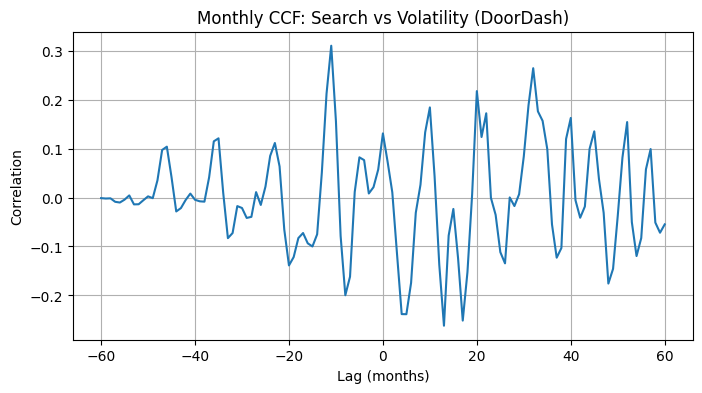

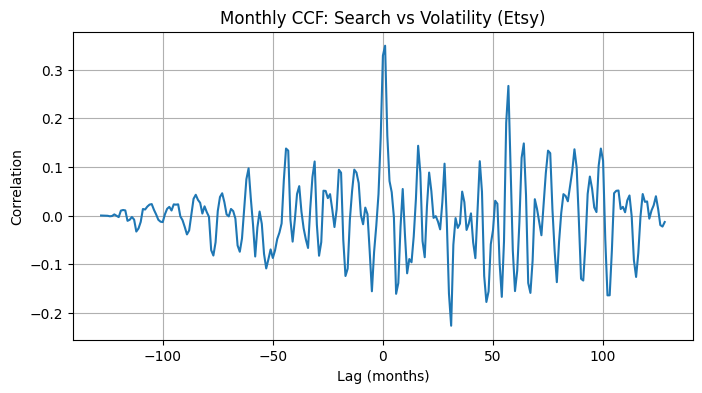

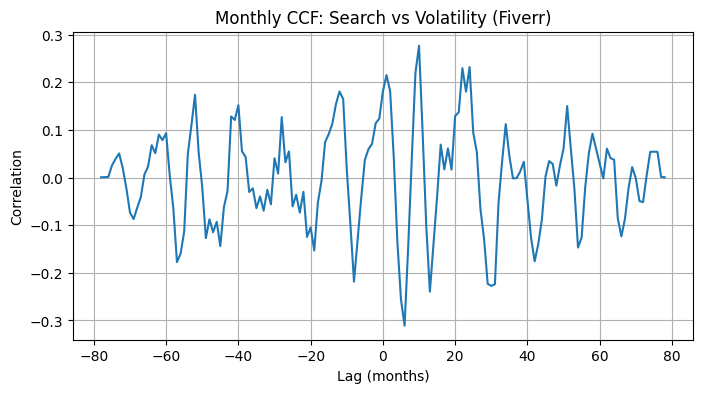

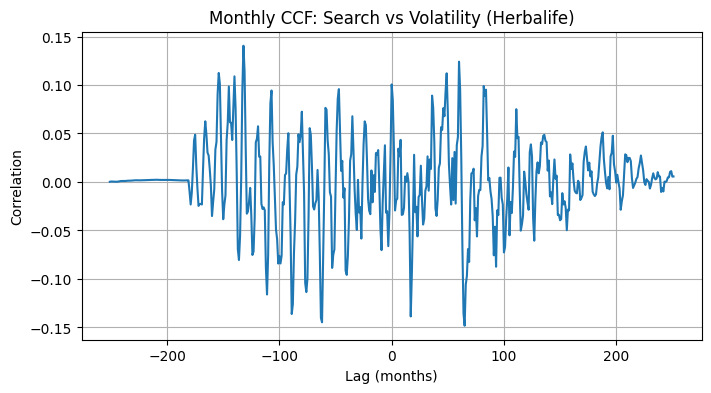

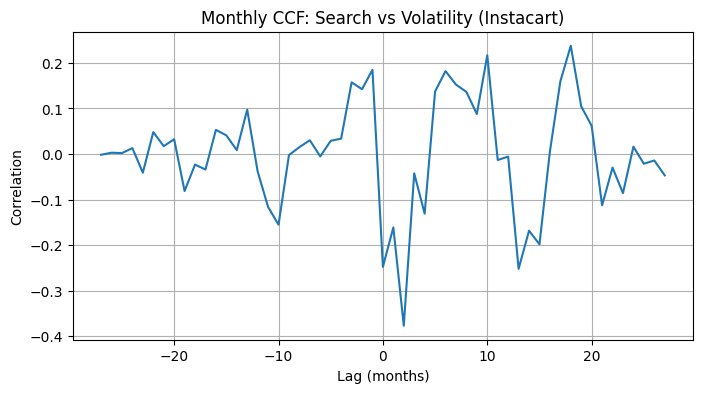

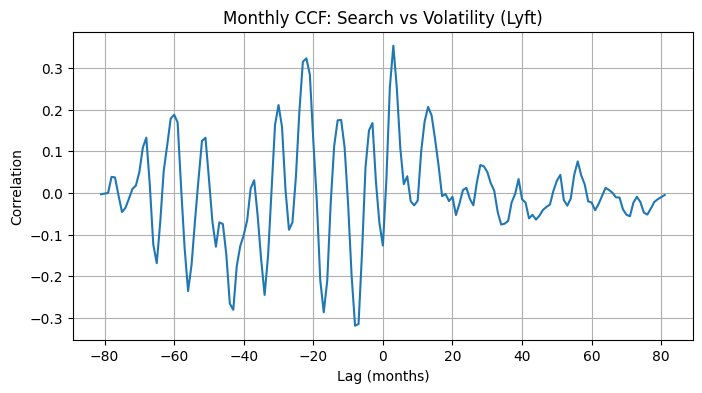

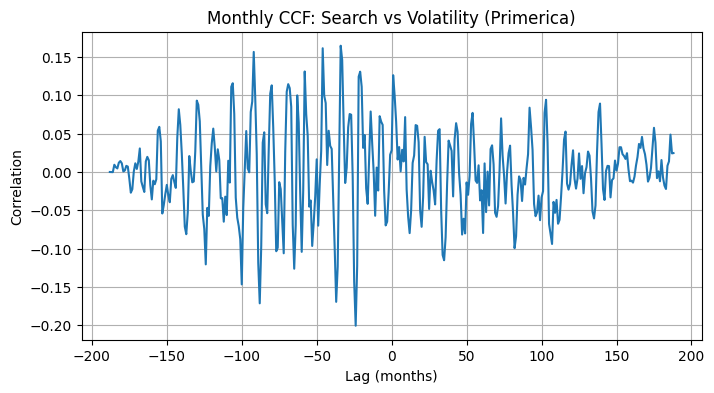

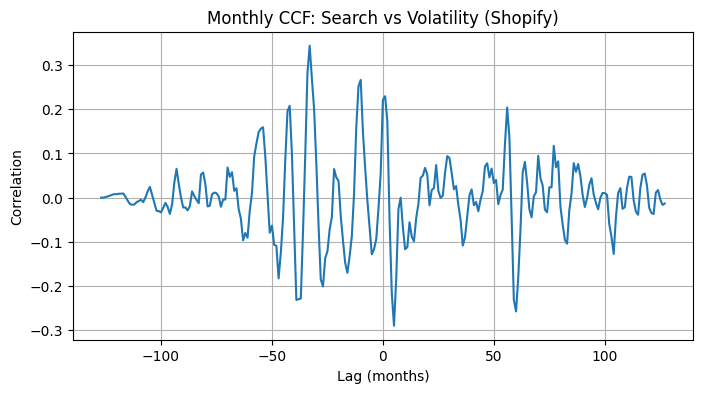

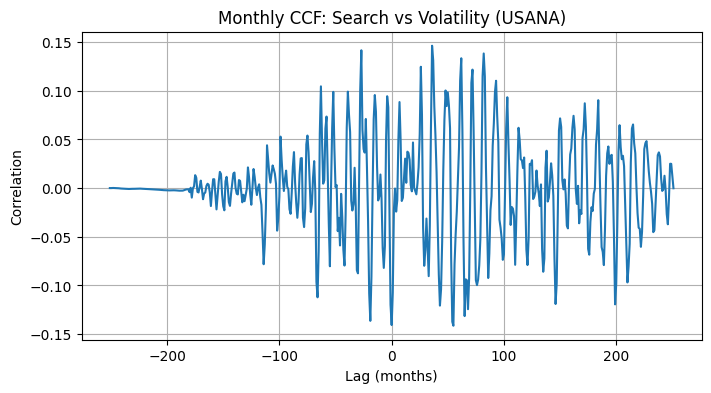

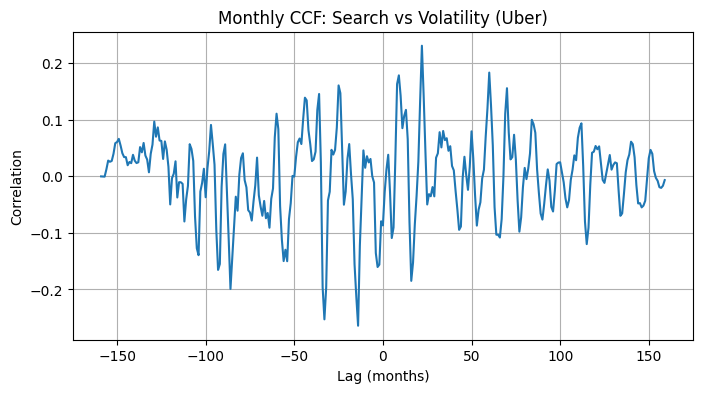

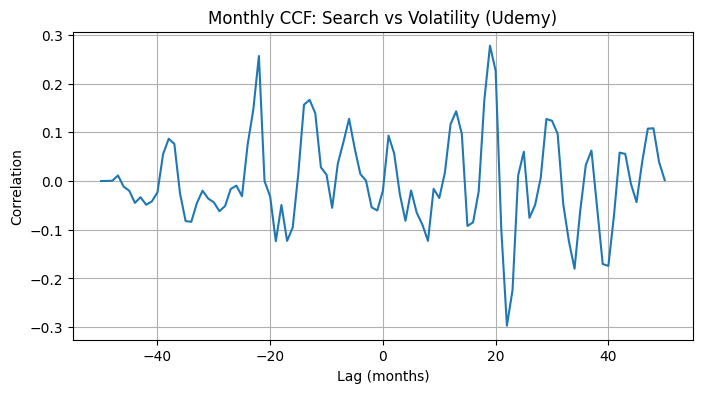

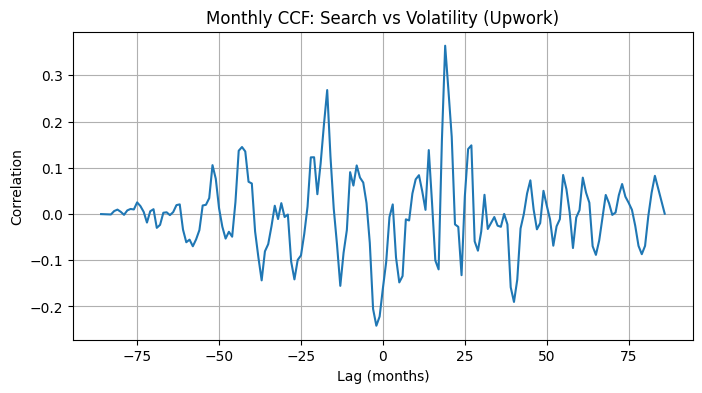

In [74]:
from statsmodels.tsa.stattools import ccf
import numpy as np
import matplotlib.pyplot as plt

companies = df['company'].unique()

for c in companies:
    temp = df[df['company'] == c].copy()
    temp = temp.sort_values(['year', 'month'])
    temp['date'] = pd.to_datetime(temp[['year','month']].assign(day=1))
    temp = temp.set_index('date')

    if temp['SearchInterest'].notna().sum() > 10:
        # Smoothed monthly change in search interest
        x = temp['SearchInterest'].diff().rolling(3).mean().fillna(0)
        # 3-month rolling volatility of returns
        y = temp['Close'].pct_change().rolling(3).std().fillna(0)

        # Normalized CCF function
        def normalized_ccf(x, y):
            x = (x - np.mean(x)) / np.std(x)
            y = (y - np.mean(y)) / np.std(y)
            return np.correlate(x, y, mode='full') / len(x)

        ccf_vals = normalized_ccf(x, y)
        lags = np.arange(-(len(x)-1), len(x))  # label lags in months

        plt.figure(figsize=(8,4))
        plt.plot(lags, ccf_vals)
        plt.title(f'Monthly CCF: Search vs Volatility ({c})')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.show()

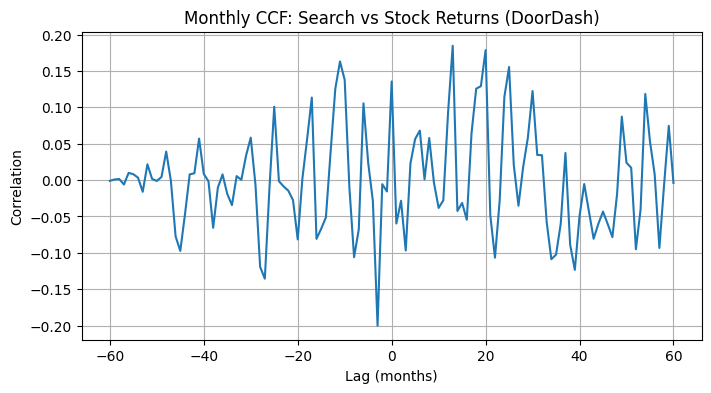

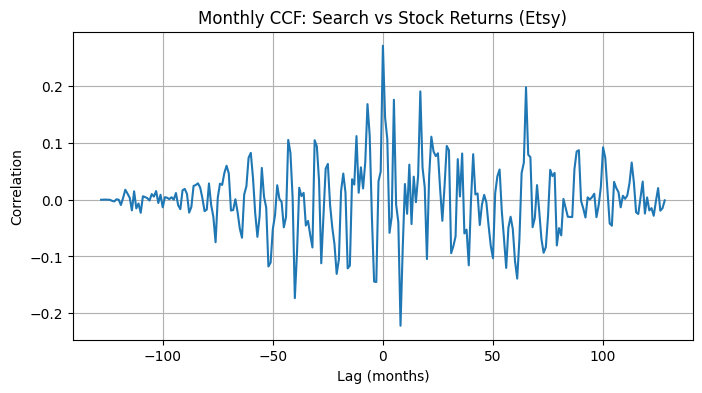

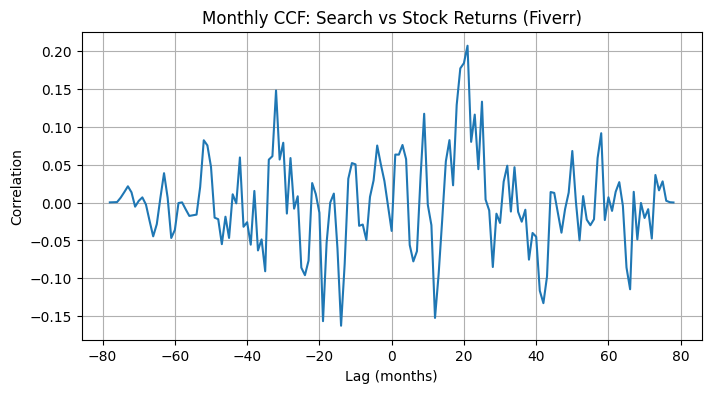

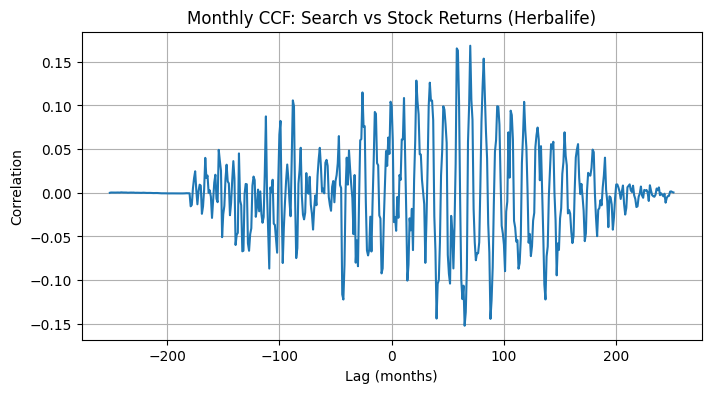

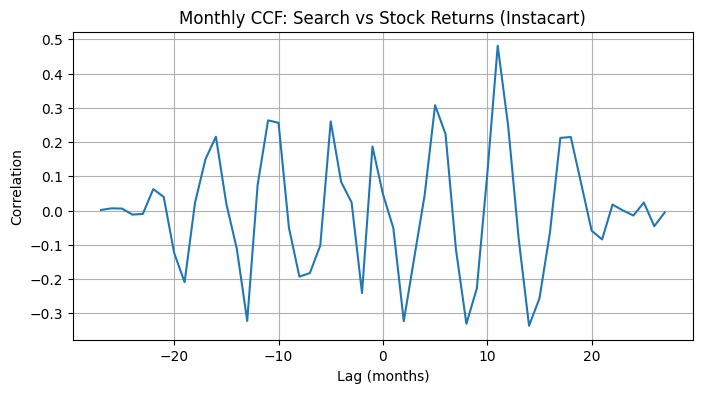

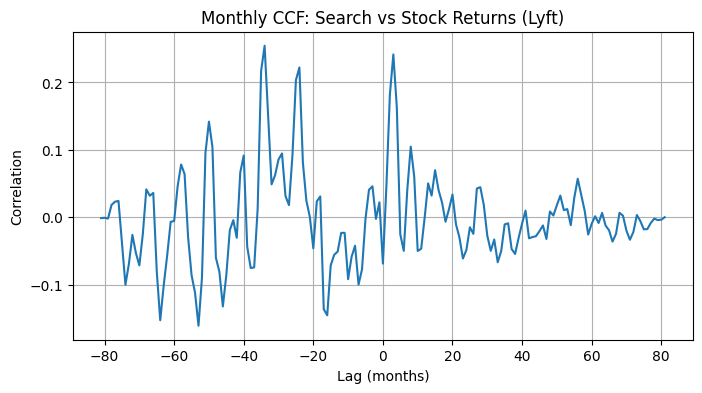

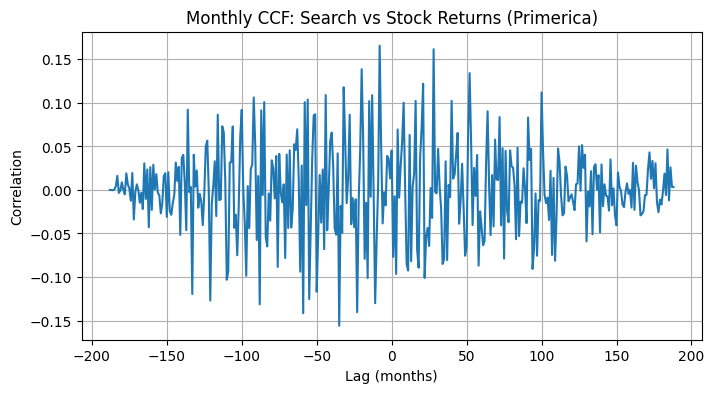

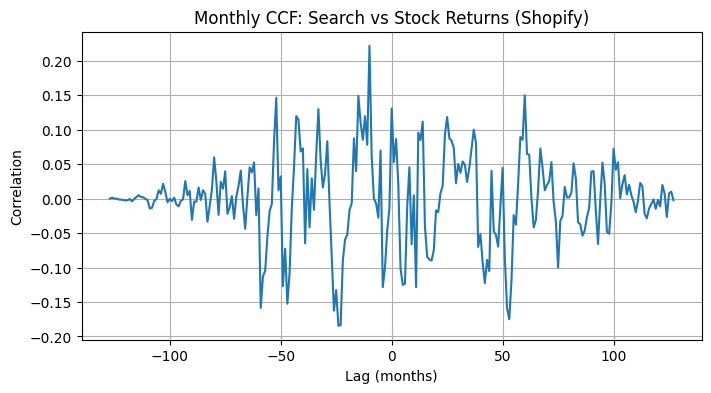

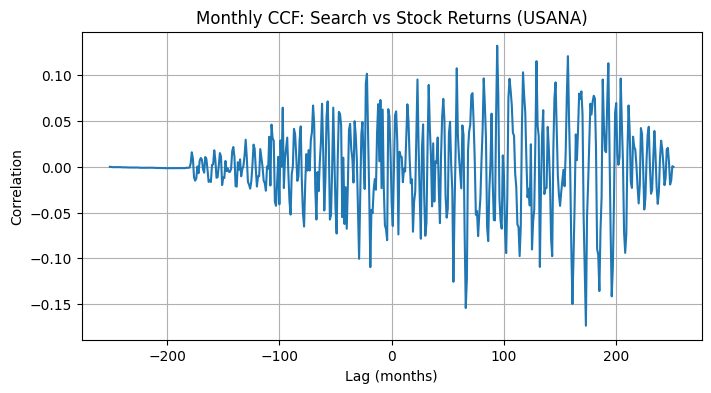

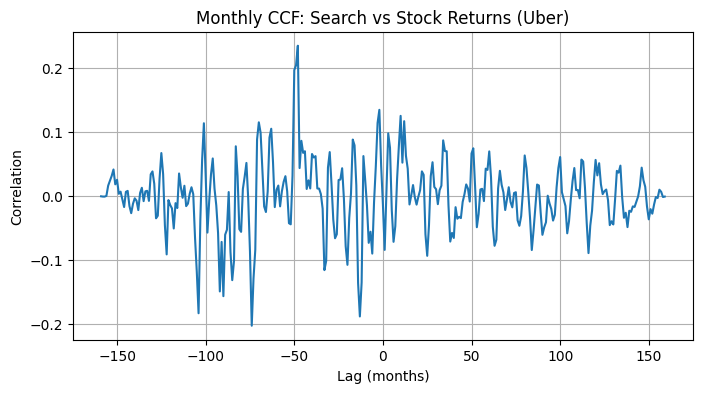

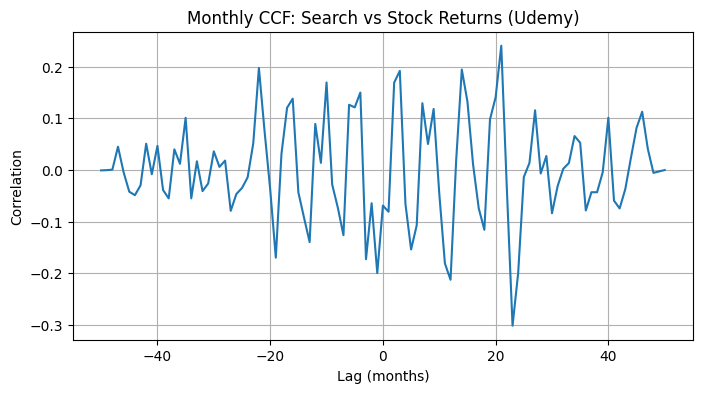

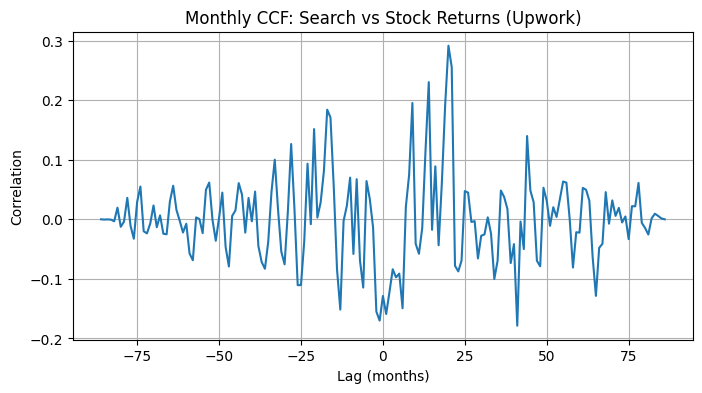

In [63]:
companies = df['company'].unique()

for c in companies:
    temp = df[df['company'] == c].copy()
    temp = temp.sort_values(['year', 'month'])
    temp['date'] = pd.to_datetime(temp[['year','month']].assign(day=1))
    temp = temp.set_index('date')

    if temp['SearchInterest'].notna().sum() > 10:
        # Smoothed monthly change in search interest
        x = temp['SearchInterest'].diff().rolling(3).mean().fillna(0)
        # 3-month rolling volatility of returns
        y = temp['Close'].pct_change().fillna(0)

        # Normalized CCF function
        def normalized_ccf(x, y):
            x = (x - np.mean(x)) / np.std(x)
            y = (y - np.mean(y)) / np.std(y)
            return np.correlate(x, y, mode='full') / len(x)

        ccf_vals = normalized_ccf(x, y)
        lags = np.arange(-(len(x)-1), len(x))  # label lags in months

        plt.figure(figsize=(8,4))
        plt.plot(lags, ccf_vals)
        plt.title(f'Monthly CCF: Search vs Stock Returns ({c})')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.show()

In [75]:
# Lagged correlations: Search_change vs Return

lags = [1, 2, 3]  # lags in months
lagged_corrs = []

companies = df['company'].unique()

for c in companies:
    temp = df[df['company']==c].sort_values(['year','month']).copy()
    temp = temp.reset_index(drop=True)

    # Ensure enough non-NaN values
    if temp['Search_change'].notna().sum() > max(lags)+2 and temp['Return'].notna().sum() > max(lags)+2:
        for lag in lags:
            # Shift Search_change forward by lag months to see if trends "lead" returns
            temp[f'Search_lead_{lag}'] = temp['Search_change'].shift(lag)
            corr_val = temp[['Return', f'Search_lead_{lag}']].dropna().corr().iloc[0,1]
            lagged_corrs.append({
                'company': c,
                'lag_months': lag,
                'lagged_corr': corr_val
            })

# Convert to DataFrame for easy viewing
lagged_corr_df = pd.DataFrame(lagged_corrs)

# Display lagged correlations
print(lagged_corr_df.head(20))

# Optional: summary by CompanyType
lagged_corr_df = lagged_corr_df.merge(df[['company','CompanyType']].drop_duplicates(), on='company', how='left')

summary_lagged = lagged_corr_df.groupby(['CompanyType','lag_months'])['lagged_corr'].mean().reset_index()
print(summary_lagged)

      company  lag_months  lagged_corr
0    DoorDash           1    -0.065082
1    DoorDash           2     0.188931
2    DoorDash           3    -0.150041
3        Etsy           1    -0.038658
4        Etsy           2     0.138997
5        Etsy           3    -0.033507
6      Fiverr           1     0.005529
7      Fiverr           2    -0.093659
8      Fiverr           3     0.082148
9   Herbalife           1     0.106179
10  Herbalife           2    -0.005630
11  Herbalife           3     0.090229
12  Instacart           1     0.262035
13  Instacart           2     0.074601
14  Instacart           3     0.022493
15       Lyft           1     0.058271
16       Lyft           2    -0.139875
17       Lyft           3     0.113246
18  Primerica           1    -0.023911
19  Primerica           2    -0.001761
  CompanyType  lag_months  lagged_corr
0         Gig           1     0.007893
1         Gig           2     0.019102
2         Gig           3    -0.026306
3         MLM           1

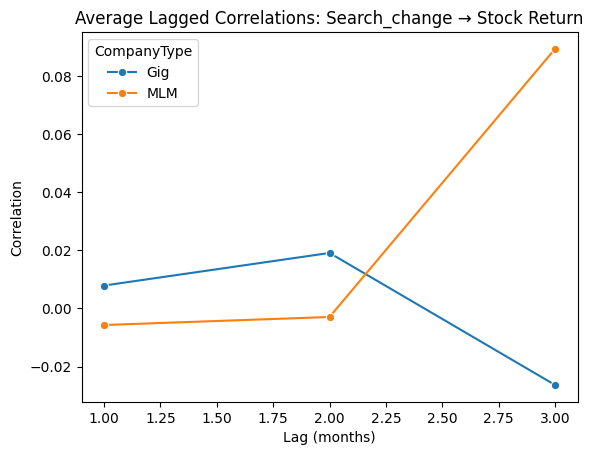

In [76]:
sns.lineplot(data=summary_lagged, x='lag_months', y='lagged_corr', hue='CompanyType', marker='o')
plt.title("Average Lagged Correlations: Search_change → Stock Return")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.show()